# 02 — Propensity score model and matching

**Goal.** Argue which covariates belong in the model, estimate P(treated | X) for each control
pool, check whether the pools contain anyone comparable, and match.

| | |
|---|---|
| **Reads** | `outputs/data/01_sample_cps.csv`, `01_sample_psid.csv` |
| **Writes** | `outputs/data/02_scored_*.csv`, `02_pairs_*.csv` |

**Questions this notebook answers**

1. Did the handoff from notebook 01 survive the CSV?
2. Which covariates belong in the model, and what is the argument for each one?
3. What do the fitted scores look like, and do the two arms overlap at all?
4. How many participants actually find a match, under which caliper, in which pool?

The two pools run as two parallel tracks and are never combined.

**One column only.** Every covariate here is a column the source files provide. Nothing is
constructed — no squares, no interactions, no recoded flags. That is a deliberate constraint while
the project is being explored: a covariate that has to be built is a modelling decision, and the
argument for it belongs beside the argument for the model, not smuggled in as data preparation.

In [1]:
import sys
sys.path.insert(0, "..")

# Reload src/ modules automatically whenever they change on disk. Without this,
# Python caches the module on first import and later edits to src/*.py are
# invisible until you restart the kernel.
%load_ext autoreload
%autoreload 2

import json
import warnings

warnings.filterwarnings("ignore", message=".*numexpr.*")
warnings.filterwarnings("ignore", message=".*bottleneck.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from src import psm, data, figures
from IPython.display import Image

pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

POOLS = ["cps", "psid"]

%matplotlib inline

## 1. Did the handoff survive?

Notebook 01 hands its work over as CSV rather than in memory, so each stage can be re-run alone.
CSV has no type system, so the dtypes chosen in notebook 01 do not make the trip.

In [2]:
samples = {pool: data.load_stage(f"01_sample_{pool}") for pool in POOLS}

chk = pd.DataFrame({
    "as built in nb01": data.load_raw("nsw_treated").dtypes,
    "after the CSV":    samples["cps"].dtypes,
}).astype(str)
chk["survived"] = chk["as built in nb01"] == chk["after the CSV"]
print(chk.to_string())

print("\nvalues are still only 0 and 1, so nothing is corrupted, only widened:")
for c in data.INDICATORS:
    print(f"  {c:10s} {sorted(samples['cps'][c].unique())}")

         as built in nb01 after the CSV  survived
treat                int8         int64     False
age               float64       float64      True
educ              float64       float64      True
black                int8         int64     False
hisp                 int8         int64     False
married              int8         int64     False
nodegree             int8         int64     False
re74              float64       float64      True
re75              float64       float64      True
re78              float64       float64      True

values are still only 0 and 1, so nothing is corrupted, only widened:
  treat      [0, 1]
  black      [0, 1]
  hisp       [0, 1]
  married    [0, 1]
  nodegree   [0, 1]


The five indicators left notebook 01 as `int8` and came back as `int64`. Nothing is broken — a CSV
stores `"0"` and pandas guesses a type on the way back in, and its guess is the widest safe one.

Re-narrowing is cheap and keeps the two notebooks honest with each other.

In [3]:
for pool, df in samples.items():
    df[data.INDICATORS] = df[data.INDICATORS].astype("int8")
    print(f"{pool:5s} {len(df):>6,} rows   treated {int(df.treat.sum()):>3d}"
          f"   treated share {df.treat.mean():>6.2%}")

assert all(int(df.treat.sum()) == 185 for df in samples.values())
print("\nthe 185 treated rows are the same people in both samples; only the control pool differs")

cps   16,177 rows   treated 185   treated share  1.14%
psid   2,675 rows   treated 185   treated share  6.92%

the 185 treated rows are the same people in both samples; only the control pool differs


## 2. Which covariates belong in the model

This is the decision the whole estimate rests on, and it is the one that cannot be checked from
inside the analysis. So it gets an explicit argument rather than a default.

### A rule about what this notebook is allowed to look at

This repository holds an experimental benchmark — the true effect is known. That creates a
temptation worth naming, because giving in to it would invalidate everything and **nothing in the
output would look wrong**: you can try covariate sets, keep whichever lands nearest the known
answer, and present the result as a validation of the method.

So the rule for this project:

> **Design decisions use only diagnostics a real study could compute** — balance, overlap, how many
> units survive. **The benchmark scores the finished pipeline. It never selects any part of it.**

Every choice below is made under that rule. Where a decision is made, the diagnostic behind it is
shown, and it is always one that exists without an answer key.

### The criterion for choosing covariates

Matching is supposed to close the **backdoor paths** between treatment and outcome — the routes by
which the two groups differ for reasons unrelated to the program. Closing them requires knowing the
causal structure, and nobody knows the full causal structure of a human life.

The practical substitute is the **disjunctive cause criterion**:

> Control for every observed variable that is a cause of the treatment, a cause of the outcome, or
> a cause of both.

It is a disjunction — "or", not "and" — so a variable earns its place by satisfying either
condition. It does not require the full graph, only that you can argue a causal role variable by
variable, which someone who knows the setting can actually do.

Two things it does not do, and both matter here:

- It says nothing about causes you failed to **observe**. Those stay open, and no amount of careful
  covariate selection closes them.
- It can admit an **instrument** — a variable that causes treatment but does not affect the outcome.
  Including one buys no bias reduction, inflates variance, and can amplify whatever bias unmeasured
  confounding is already causing. None of the eight below is plausibly a pure instrument: every one
  has a direct route to earnings. So the criterion is safe to apply here, not everywhere.

In [4]:
# The DAG declared as data. This single list drives both the figure and the table,
# so the picture and the prose cannot drift apart.
DAG = [
    dict(name="age", causes_treatment=True, causes_outcome=True,
         why_treatment="eligibility strata were age-defined (17-20 year old dropouts)",
         why_outcome="earnings rise with labor market experience"),
    dict(name="educ", causes_treatment=True, causes_outcome=True,
         why_treatment="the dropout stratum required incomplete schooling",
         why_outcome="human capital: each year of schooling raises earnings"),
    dict(name="nodegree", causes_treatment=True, causes_outcome=True,
         why_treatment="same eligibility route as educ; the credential is what the stratum lacked",
         why_outcome="employers screen on the credential, not only on years"),
    dict(name="black", causes_treatment=True, causes_outcome=True,
         why_treatment="recruitment sites reached this population differentially",
         why_outcome="labor market discrimination depresses earnings"),
    dict(name="hisp", causes_treatment=True, causes_outcome=True,
         why_treatment="recruitment sites reached this population differentially",
         why_outcome="labor market discrimination depresses earnings"),
    dict(name="married", causes_treatment=True, causes_outcome=True,
         why_treatment="the AFDC stratum was women with dependent children",
         why_outcome="household structure shifts labor supply and reservation wage"),
    dict(name="re74", causes_treatment=True, causes_outcome=True,
         why_treatment="eligibility required long-term detachment from work",
         why_outcome="earnings are highly persistent year to year"),
    dict(name="re75", causes_treatment=True, causes_outcome=True,
         why_treatment="eligibility required long-term detachment from work",
         why_outcome="earnings are highly persistent year to year"),
]

print(f"{len(DAG)} covariates, every one a cause of treatment AND of the outcome\n")
for d in DAG:
    print(f"  {d['name']:9s} T: {d['why_treatment']}")
    print(f"  {'':9s} Y: {d['why_outcome']}")

assert {d["name"] for d in DAG} == set(data.covariate_spec("with_earnings")), \
    "the DAG and the stored spec must select the same covariates"
COVARIATES = data.covariate_spec("with_earnings")
print(f"\nmatches data.covariate_spec('with_earnings'):\n  {COVARIATES}")

8 covariates, every one a cause of treatment AND of the outcome

  age       T: eligibility strata were age-defined (17-20 year old dropouts)
            Y: earnings rise with labor market experience
  educ      T: the dropout stratum required incomplete schooling
            Y: human capital: each year of schooling raises earnings
  nodegree  T: same eligibility route as educ; the credential is what the stratum lacked
            Y: employers screen on the credential, not only on years
  black     T: recruitment sites reached this population differentially
            Y: labor market discrimination depresses earnings
  hisp      T: recruitment sites reached this population differentially
            Y: labor market discrimination depresses earnings
  married   T: the AFDC stratum was women with dependent children
            Y: household structure shifts labor supply and reservation wage
  re74      T: eligibility required long-term detachment from work
            Y: earnings are hig

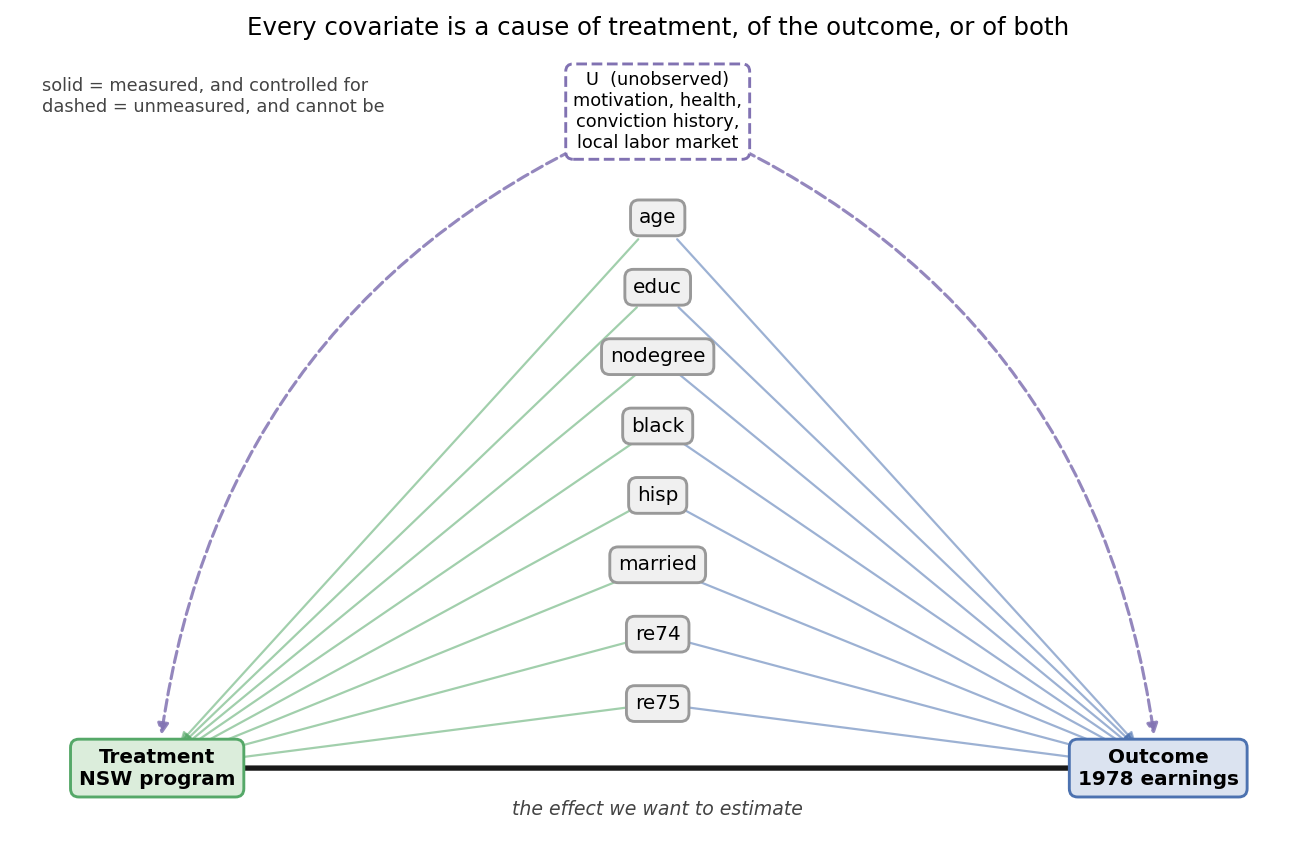

In [5]:
figures.dag_plot(DAG, "dag",
                 title="Every covariate is a cause of treatment, of the outcome, or of both")
Image(filename="../outputs/figures/psm_dag.png")

### What the picture is telling you

Every solid arrow points **into** treatment or outcome. Nothing points out of them, and that is the
claim being made rather than decoration. A variable with an arrow *from* treatment would be a
consequence of the program, and conditioning on it would destroy the estimate.

The dashed box is the honest part. **Motivation, health, addiction or conviction history, and the
local labor market are causes of both arms, and none of them is in the file.** The criterion covers
observed causes; these are not observed. So the backdoor is narrowed, not closed, and every estimate
downstream is conditional on those arrows being weak. Nothing in the analysis can tell us whether
they are.

### What is excluded, and why

- **`re78` is the outcome.** It never enters the model or a balance check. Conditioning on the
  outcome builds the answer into the design.
- **Anything measured after treatment.** A variable like "employed in 1978" sits *downstream* of the
  program, which makes it a **mediator**: part of how the program raises earnings is by getting
  people employed at all. Conditioning on a mediator removes exactly the part of the effect you are
  trying to measure.
- **Constructed columns.** Squares, interactions and recoded flags are functional-form choices, not
  causes, and no DAG argument selects them. They are out of scope for now.

The general rule is easier to remember than the special cases: **nothing measured after treatment
may be a covariate.** All eight above were measured before anyone was assigned.

## 3. Fitting the model

One logistic regression per pool: participants against CPS, and participants against PSID. Two
separate fits, never one pooled fit. The 185 treated rows are identical in both, so any difference
between the models is a difference between the control pools.

### Why plain logistic regression, with no penalty

`scikit-learn`'s `LogisticRegression` does **not** fit a plain logistic regression by default. It
fits a **penalized** one, and the default is silent.

An ordinary logistic regression picks the coefficients β that best fit the observed treatment
labels. A penalized one minimizes something else:

$$-\log\mathcal{L}(\beta) \;+\; \frac{1}{C}\sum_j \beta_j^2$$

That second term is the **L2 penalty**: the sum of squared coefficients. It is a fine for having
large coefficients, so every β is pulled toward zero. (The L1 alternative, $\sum_j|\beta_j|$, pushes
some coefficients to *exactly* zero and performs feature selection. L2 shrinks all of them smoothly
instead.)

**`C` is the inverse penalty strength, which runs backwards from intuition:**

| `C` | penalty weight `1/C` | effect |
|---|---|---|
| 0.01 | 100 | heavy fine — coefficients squashed toward zero |
| 1.0 | 1 | moderate — **scikit-learn's default** |
| 10⁶ | 0.000001 | negligible — plain, unpenalized logistic regression |

So a **bigger** `C` means **less** regularization.

**Why none of it here.** Regularization exists to stop a model chasing noise in its training data so
it generalizes to data it has not seen. That is a prediction problem, and this is not one. No one
will ever apply this model to a new person. Its only job is to produce a number such that,
conditioning on it, the two groups' covariate distributions line up.

**And the honest version of the argument:** the reason is parsimony, not measured superiority. On
this covariate set the balance evidence does not pick a winner — CPS is better balanced at `C=1`
(max |SMD| 0.240 against 0.307), PSID at no penalty (0.140 against 0.199). The two pools disagree,
so any data-driven pick is itself a selection. The model with no tuning constant is used because
nothing about it has to be defended from the data.

What would *not* be acceptable, under the rule in section 2: choosing `C` by seeing which value
lands nearest $1,794. That option does not exist in a real study.

In [6]:
scored = {}
for pool, df in samples.items():
    X, t = df[COVARIATES], df.treat.values
    df = df.copy()
    df["prop_score"] = psm.fit_propensity(X, t, model="logit")   # C defaults to psm.NO_PENALTY
    scored[pool] = df
    print(f"{pool:5s} fitted on {len(df):>6,} rows, {len(COVARIATES)} covariates, "
          f"C = {psm.NO_PENALTY:,.0f} (unpenalized)")

cps   fitted on 16,177 rows, 8 covariates, C = 1,000,000 (unpenalized)
psid  fitted on  2,675 rows, 8 covariates, C = 1,000,000 (unpenalized)


In [7]:
coefs = {}
for pool, df in scored.items():
    clf = LogisticRegression(C=psm.NO_PENALTY, max_iter=2000).fit(
        StandardScaler().fit_transform(df[COVARIATES]), df.treat.values)
    coefs[pool] = pd.Series(clf.coef_[0], index=COVARIATES)

co = pd.DataFrame(coefs).round(2)
print("coefficients on STANDARDIZED covariates, so magnitudes are comparable")
print(co.reindex(co.abs().max(axis=1).sort_values(ascending=False).index).to_string())

coefficients on STANDARDIZED covariates, so magnitudes are comparable
           cps  psid
re75     -1.97 -3.63
re74     -0.28 -1.50
black     1.16  1.00
age      -0.04 -0.83
married  -0.45 -0.63
nodegree  0.47  0.36
hisp      0.46  0.37
educ      0.10  0.12


`re75` carries the largest coefficient in both pools by a wide margin, and it is **negative** —
more 1975 earnings, lower probability of having been a participant. That is the DAG's strongest
arrow appearing in the fit: eligibility was effectively defined by not having worked, so 1975
earnings is close to the assignment rule itself. A positive sign here would have meant something
was wrong.

In [8]:
print("AUC - a sanity check, NOT an objective\n")
for pool, df in scored.items():
    auc = roc_auc_score(df.treat, df.prop_score)
    c0 = df.loc[df.treat == 0, "prop_score"]
    print(f"  {pool:5s} AUC = {auc:.3f}   |   {int((c0 < 0.001).sum()):>6,} of {len(c0):,} controls "
          f"score below 0.001")

AUC - a sanity check, NOT an objective

  cps   AUC = 0.971   |   10,734 of 15,992 controls score below 0.001
  psid  AUC = 0.977   |    1,585 of 2,490 controls score below 0.001


### Reading the AUC

0.97 on both. On a prediction problem those would be excellent. Here they are a warning.

AUC measures how well the model **separates** participants from survey respondents. Near 1 means the
two groups are almost perfectly distinguishable from covariates alone — that age, schooling and
prior earnings are nearly enough to say which group someone came from.

That is bad news for matching, which needs the opposite: control units whose covariates make them
*plausible* participants. The counts beside the AUC say it in people rather than in
area-under-a-curve: **10,734 of 15,992 CPS respondents score below 0.001**, and 1,585 of 2,490 in
PSID. Two thirds of each pool is not a plausible comparison for anyone in the program.

So the AUC is reported as a **property of the data**, not a score for the model. A low AUC would
have meant the groups were genuinely similar, which is the easy case. We do not have the easy case.

## 4. Common support, before any matching

Matching can only work where the two arms occupy the same region of the score. That has to be looked
at before matching, not after, because matching will quietly produce *some* answer either way.

The question: **does the control distribution cover the treated range, with enough density to draw
from?**

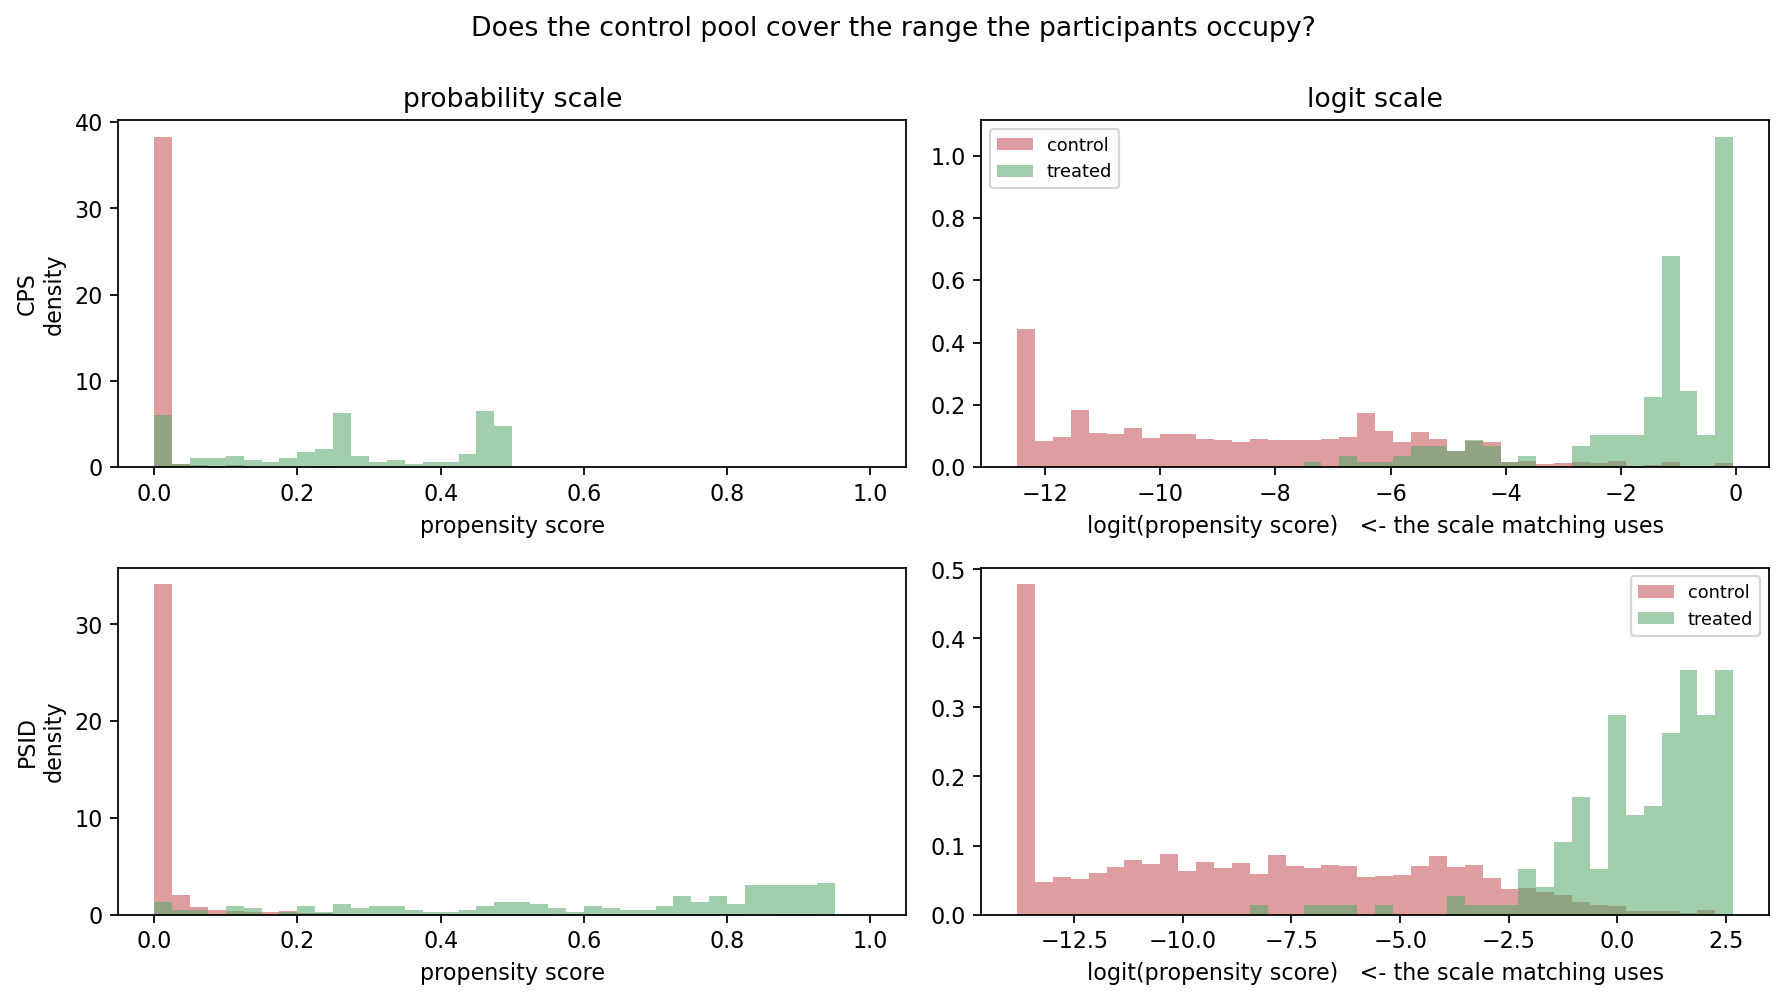

In [9]:
panels = [(pool.upper(), scored[pool].prop_score.values, scored[pool].treat.values)
          for pool in POOLS]
figures.common_support_plot(
    panels, "common_support",
    title="Does the control pool cover the range the participants occupy?")
Image(filename="../outputs/figures/psm_common_support.png")

In [10]:
sup = {}
for pool, df in scored.items():
    ps, t = df.prop_score.values, df.treat.values == 1
    hi = np.quantile(ps[~t], 0.999)
    sup[pool.upper()] = {
        "controls in [0, 0.025)":      f"{(ps[~t] < 0.025).mean():.1%}",
        "controls below 0.001":        f"{(ps[~t] < 0.001).mean():.1%}",
        "control 99.9th percentile":   round(float(hi), 3),
        "treated above it":            f"{int((ps[t] > hi).sum())} / {int(t.sum())}",
        "treated score range":         f"[{ps[t].min():.4f}, {ps[t].max():.4f}]",
    }
print(pd.DataFrame(sup).T.to_string())

     controls in [0, 0.025) controls below 0.001 control 99.9th percentile treated above it treated score range
CPS                   95.7%                67.1%                      0.48         20 / 185    [0.0007, 0.4874]
PSID                  85.4%                63.7%                      0.90         29 / 185    [0.0002, 0.9350]


### Reading the figure

**Two scales, because either one alone misleads.**

On the **probability scale** (left) the control group collapses into the leftmost bar — 95.7% of CPS
controls sit below 0.025. That bar *is* a finding, but it hides everything happening where matching
actually occurs.

On the **logit scale** (right) the crowded ends are stretched apart, and this is the scale the
caliper is applied on, so it is the panel to read for overlap.

**CPS:** the arms do overlap through the middle, but the treated mass concentrates at the right edge
where control density is thinning. 20 of 185 participants score above the 99.9th percentile of the
entire CPS control distribution.

**PSID:** look at the right end of the bottom-right panel. The treated bars stand where there is
essentially **no red underneath them at all**. 29 of 185 participants sit above the control
distribution's 99.9th percentile, and a large block above where control density has effectively
ended. There is no one to match them to — not few, none.

This is what the caliper is about to act on, and the two pools are about to behave very differently.

## 5. One-to-one matching

Each participant gets at most one control, and each control is used at most once. A participant is
only allowed a partner if that partner is close enough — the **caliper**.

### The two calipers, and how they differ

**Caliper on the raw probability scale, width 0.01.** A pair is allowed when

$$|\,\hat e_{\text{treated}} - \hat e_{\text{control}}\,| \le 0.01$$

**Caliper on the logit scale, width 0.2 standard deviations.** A pair is allowed when

$$\bigl|\,\text{logit}(\hat e_{\text{treated}}) - \text{logit}(\hat e_{\text{control}})\,\bigr|
\;\le\; 0.2 \times \text{SD}\bigl(\text{logit}(\hat e)\bigr)$$

The comparison happens on **different scales**, and that is the whole difference. Section 4 showed
the scores crushed against zero; on the probability scale a gap of 0.01 down there can separate
people who are worlds apart in relative terms, while near 0.5 it barely distinguishes anyone. The
logit stretches the crowded ends apart, so a caliper in logit-SD units means something comparable
wherever on the scale you happen to be.

Caliper matching on the logit is Rosenbaum & Rubin (1985). The 0.2 figure comes from Austin (2011),
"Optimal caliper widths for propensity-score matching", which found it close to optimal in
simulation.

**A note on how the matching runs.** It is greedy: participants are visited one at a time, each
taking the nearest still-available control. Greedy matching depends on the visiting order, so the
order is randomized and seeded. The specific pairs therefore depend on the seed even where the
counts are stable.

In [11]:
CALIPERS = {
    "0.01, raw probability scale": dict(caliper=0.01, scale="raw"),
    "0.2 x SD(logit)":             dict(caliper=0.2,  scale="logit"),
}

# what the 0.2 rule actually works out to, in the units it is applied in
for pool, df in scored.items():
    sd = psm.logit(df.prop_score.values).std()
    print(f"{pool:5s} SD(logit(ps)) = {sd:.3f}   ->   caliper width = 0.2 x {sd:.3f} = {0.2*sd:.3f}"
          f"   (logit units)")
print("\nthe same rule gives a different absolute width in each pool, which is the point of "
      "expressing it in SD")

cps   SD(logit(ps)) = 2.997   ->   caliper width = 0.2 x 2.997 = 0.599   (logit units)
psid  SD(logit(ps)) = 4.609   ->   caliper width = 0.2 x 4.609 = 0.922   (logit units)

the same rule gives a different absolute width in each pool, which is the point of expressing it in SD


In [12]:
pairs, report = {}, []
for pool, df in scored.items():
    ps, t = df.prop_score.values, df.treat.values
    n_treated = int(t.sum())
    for label, kw in CALIPERS.items():
        pr = psm.nn_match(ps, t, replace=False, seed=0, **kw)
        pairs[(pool, label)] = pr
        matched = set(pr.treated.values)
        unmatched = [i for i in np.flatnonzero(t == 1) if i not in matched]
        report.append({
            "pool": pool.upper(), "caliper": label,
            "treated": n_treated, "matched": len(pr), "unmatched": len(unmatched),
            "% unmatched": f"{len(unmatched) / n_treated:.1%}",
            "ps of matched":   round(float(ps[list(matched)].mean()), 3),
            "ps of unmatched": round(float(ps[unmatched].mean()), 3) if unmatched else None,
        })

print("ONE-TO-ONE MATCHING, no replacement, 185 participants in each pool")
print(pd.DataFrame(report).to_string(index=False))

ONE-TO-ONE MATCHING, no replacement, 185 participants in each pool
pool                     caliper  treated  matched  unmatched % unmatched  ps of matched  ps of unmatched
 CPS 0.01, raw probability scale      185      177          8        4.3%           0.26             0.43
 CPS             0.2 x SD(logit)      185      185          0        0.0%           0.27              NaN
PSID 0.01, raw probability scale      185       80        105       56.8%           0.43             0.80
PSID             0.2 x SD(logit)      185       94         91       49.2%           0.45             0.83


### How many participants found a partner

**CPS.** The logit caliper matches **all 185**. The 0.01 probability caliper misses 8. Both are
workable, and the difference is the scale point above: 0.01 is a narrow absolute width in the region
where most of these scores live.

**PSID.** Neither caliper can match half the participants. The 0.01 caliper leaves **105 of 185
unmatched (56.8%)**, and the logit caliper **91 (49.2%)**.

And look at the last two columns. In PSID the unmatched participants have a *higher* average
propensity score than the matched ones — **0.834 against 0.445**. The people who look **most** like
program participants are precisely the ones with no counterpart. That is section 4's right-hand tail
with no red underneath it, now expressed as a headcount.

In [13]:
pool, label = "psid", "0.2 x SD(logit)"
df = scored[pool]
t = df.treat.values
matched = set(pairs[(pool, label)].treated.values)
got  = [i for i in np.flatnonzero(t == 1) if i in matched]
miss = [i for i in np.flatnonzero(t == 1) if i not in matched]

cmp = pd.DataFrame({
    f"matched (n={len(got)})":   df.iloc[got][COVARIATES].mean(),
    f"unmatched (n={len(miss)})": df.iloc[miss][COVARIATES].mean(),
})
cmp["difference"] = cmp.iloc[:, 1] - cmp.iloc[:, 0]
print("PSID: who the matching keeps, and who it drops")
print(cmp.round(2).to_string())

PSID: who the matching keeps, and who it drops
          matched (n=94)  unmatched (n=91)  difference
age                28.35             23.20       -5.15
educ               10.47             10.22       -0.25
black               0.76              0.93        0.18
hisp                0.06              0.05       -0.01
married             0.33              0.04       -0.29
nodegree            0.64              0.78        0.14
re74            3,689.58            449.01   -3,240.57
re75            2,592.58            436.56   -2,156.02


### What PSID actually drops

The participants PSID cannot match are **younger** (23.2 against 28.4), **more likely to be Black**
(93% against 76%), **almost never married** (4% against 33%), and had **essentially no prior
earnings** ($449 against $3,690 in 1974).

That is not a random half. It is the **most disadvantaged half of the program** — which is the
population the program was built for. PSID simply contains nobody who looks like them.

#### The consequence: the estimand changes

The ATT is defined over the people who actually took the program — all 185 of them. Drop 91 and
whatever comes out is no longer the ATT. It is the effect for the 94 least disadvantaged
participants, a group chosen not by design but by which control pool happened to be available.

**Nothing in a standard matching output reveals this.** You would see 94 pairs, a balance table that
looks acceptable, and a confidence interval. The estimand quietly changed and the diagnostics stayed
green.

#### Decision: PSID is not carried into the analysis

Losing 49% of the treated units is disqualifying. The PSID result stays in the notebook because it
is the evidence for *why* — a control pool can look like a perfectly reasonable comparison group and
turn out to have no counterpart for half the people you care about.

Worth noting **how** this decision was reached: match rate and common support. Both are computable
in any real study, with no answer key required. This is the rule from section 2 doing its job.

The analysis continues on **CPS**, where all 185 participants matched.

## 6. Hand off to notebook 03

Two files per pool: the scored sample, and the matched pairs. PSID's are written too — a
disqualified result still has to be reproducible.

In [14]:
HEADLINE_CALIPER = "0.2 x SD(logit)"

for pool, df in scored.items():
    keep = ["treat"] + COVARIATES + ["re78", "prop_score"]
    p1 = data.save_stage(df[keep], f"02_scored_{pool}")
    p2 = data.save_stage(pairs[(pool, HEADLINE_CALIPER)], f"02_pairs_{pool}")
    print(f"{p1.name:22s} {df.shape[0]:>6,} rows x {len(keep)} cols")
    print(f"{p2.name:22s} {len(pairs[(pool, HEADLINE_CALIPER)]):>6,} pairs "
          f"of {int(df.treat.sum())} participants"
          f"{'' if pool == 'cps' else '   <- disqualified, see section 5'}")

02_scored_cps.csv      16,177 rows x 11 cols
02_pairs_cps.csv          185 pairs of 185 participants
02_scored_psid.csv      2,675 rows x 11 cols
02_pairs_psid.csv          94 pairs of 185 participants   <- disqualified, see section 5
